<a href="https://colab.research.google.com/github/marutipatil1/CSL701-CE35_Machine-Learning-Lab/blob/main/Experiment/CE35exp5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Aim : To implement a Bagging (Bootstrap Aggregating) ensemble classifier from scratch using Python, apply it to the Pima Indians Diabetes Database, and evaluate its performance against a single base classifier (Decision Tree)**.


## Objectives

1. Understand Ensemble Learning Principles: Comprehend how combining the predictions of multiple diverse models reduces overall model variance.
2. Master Bootstrapping: Implement random resampling of data with replacement from scratch to generate distinct training subsets.
3. Develop a Voting System: Build an aggregation mechanism (Majority Voting) from scratch to consolidate predictions.
4. Learn Baseline Evaluation: Compare the performance of a high-variance, low-bias single decision tree against the more stable Bagging ensemble.
5. Analyze Performance Metrics: Calculate and visualize classification metrics, including a Confusion Matrix, Accuracy, Precision, Recall, and ROC-AUC curve.


Relevant Theory
Ensemble Methods and Bagging
Ensemble learning combines several individual classifiers (base learners) to produce a unified model that generalizes better than any single model on unseen data. Bootstrap Aggregating (Bagging) is a parallel ensemble method designed primarily to reduce variance. High-variance models—such as deep, fully-grown decision trees—are highly sensitive to small changes in their training datasets. Bagging addresses this by smoothing out individual model errors without increasing bias.

The two core components of Bagging are:

1. Bootstrapping (Sampling with Replacement): For a training set of size $N$, we generate $B$ new datasets of the same size $N$. Each instance is selected at random from the original dataset with replacement. This means a single instance can be selected multiple times, while on average, only about 63.2% of the unique training samples are captured in each bootstrap, leaving the rest as out-of-bag (OOB) samples.
2. Aggregating (Majority Voting): A separate base learner $h_b(x)$ is trained independently on each bootstrap sample. For classification, predictions are aggregated by passing a test sample to all $B$ models and taking a majority vote: $$\hat{G}{\text{bag}}(x) = \text{argmax}{k} \sum_{b=1}^{B} I(h_b(x) = k)$$

An alternative to standard Bagging is subagging (subsample aggregating), where smaller training subsets (often $N/2$) are drawn without replacement to reduce correlation and accelerate computation.

---
## Software Requirements

- **Language:** Python 3.x

- **Core Libraries:**
  - **NumPy** for matrix manipulation and custom bootstrapping operations.
  - **Pandas** for loading, indexing, and cleaning tabular data.
  - **Matplotlib / Seaborn** for exploratory scatter plots, bar charts, and performance visualization.
  - **Scikit-learn** for train-test splitting, training individual base decision trees, and comparison with built-in Bagging algorithms.

---

## Dataset Information

The experiment utilizes the **Pima Indians Diabetes Database** from the UCI Machine Learning Repository. The dataset contains medical details for 768 female Pima Indian patients living in Arizona, categorized as either diabetic or non-diabetic.

- **Total Instances:** 768

- **Features (8 predictor variables):**
  1. **`Pregnancies`**: Number of times pregnant.
  2. **`Glucose`**: Plasma glucose concentration over 2 hours in an oral glucose tolerance test.
  3. **`BloodPressure`**: Diastolic blood pressure (mm Hg).
  4. **`SkinThickness`**: Triceps skin fold thickness (mm).
  5. **`Insulin`**: 2-Hour serum insulin ($\mu$U/ml).
  6. **`BMI`**: Body mass index (weight in kg/m$^2$).
  7. **`DiabetesPedigreeFunction`**: A function representing genetic predisposition.
  8. **`Age`**: Age of the subject in years.

- **Target Label (9th column):** **`Outcome`**
  - **0** represents non-diabetic.
  - **1** represents diabetic.

## Experimental Tasks

### Task 1: Environment Setup and Dataset Acquisition

Use dataset using the link  
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Goal:** Set up the workspace and load the data.

**Instructions:**

1. Import the necessary modules: **`numpy`**, **`pandas`**, **`matplotlib.pyplot`**, and **`sklearn`**.

2. Load the file **`pima-indians-diabetes.data`** into a Pandas DataFrame, assigning appropriate column headers.

3. Print the following:
   - First five records of the dataset.
   - Dataset shape, expected to be $768 \times 9$.
   - Data types of all features.
   - Descriptive statistics of the numeric features.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
import seaborn as sns

# Define column headers as per dataset description
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

# Load the dataset, letting pandas infer the header from the first row of the CSV.
# Then, explicitly assign the defined column_names to ensure consistency.
df = pd.read_csv('/content/diabetes.csv')
df.columns = column_names

# Print the first five records
print("First five records of the dataset:")
display(df.head())

# Print dataset shape
print(f"\nDataset shape: {df.shape}")

# Print data types of all features
print("\nData types of all features:")
display(df.dtypes)

# Print descriptive statistics of the numeric features
print("\nDescriptive statistics of the numeric features:")
display(df.describe())

First five records of the dataset:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Dataset shape: (768, 9)

Data types of all features:


,0
Pregnancies,int64
Glucose,int64
BloodPressure,float64
SkinThickness,int64
Insulin,float64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64



Descriptive statistics of the numeric features:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Task 2: Exploratory Data Analysis (EDA)

**Goal:** Visually inspect feature distributions and class balance.

**Instructions:**

1. Calculate the **absolute count** and **percentage** of diabetic (`Outcome = 1`) and non-diabetic (`Outcome = 0`) cases. Plot the class balance using a **bar chart**.

2. Create a **scatter plot** of **`Age`** (Feature 7) against **`Glucose`** (Feature 1), color-coded according to the target variable **`Outcome`**.

3. Briefly explain why a simple linear decision boundary is insufficient to clearly separate the diabetic and non-diabetic classes.

Absolute count of Outcome classes:
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of Outcome classes:
Outcome
0    65.104167
1    34.895833
Name: proportion, dtype: float64


/tmp/ipykernel_1081/4216055196.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')


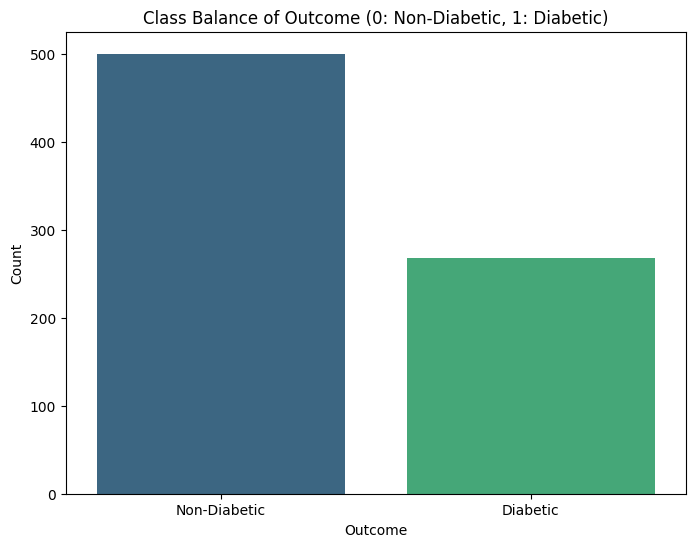

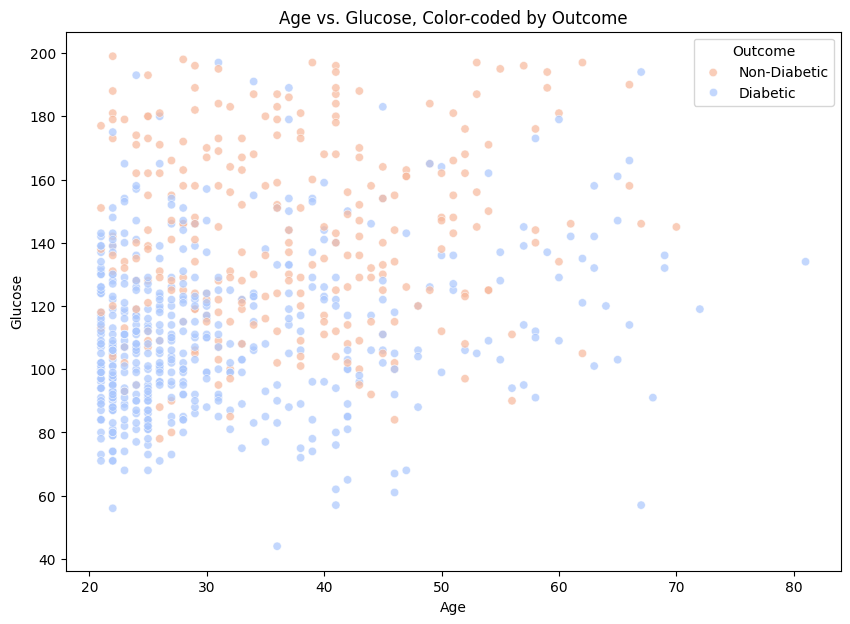

In [3]:
# 1. Calculate and plot class balance
class_counts = df['Outcome'].value_counts()
class_percentages = df['Outcome'].value_counts(normalize=True) * 100

print("Absolute count of Outcome classes:")
print(class_counts)
print("\nPercentage of Outcome classes:")
print(class_percentages)

plt.figure(figsize=(8, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, palette='viridis')
plt.title('Class Balance of Outcome (0: Non-Diabetic, 1: Diabetic)')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Non-Diabetic', 'Diabetic'])
plt.show()

# 2. Create a scatter plot of Age against Glucose, color-coded by Outcome
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df, x='Age', y='Glucose', hue='Outcome', palette='coolwarm', alpha=0.7)
plt.title('Age vs. Glucose, Color-coded by Outcome')
plt.xlabel('Age')
plt.ylabel('Glucose')
plt.legend(title='Outcome', labels=['Non-Diabetic', 'Diabetic'])
plt.show()


### Explanation for Task 2.3:

Looking at the scatter plot of 'Age' vs. 'Glucose' color-coded by 'Outcome', it is evident that the diabetic (red) and non-diabetic (blue) instances are not linearly separable. The two classes extensively overlap, particularly in the central region of the plot. There isn't a clear straight line that can effectively distinguish between diabetic and non-diabetic patients with high accuracy. This non-linear distribution suggests that a simple linear decision boundary would result in a significant number of misclassifications, indicating that more complex models or non-linear decision boundaries are needed for accurate classification.

#### **Task 3: Preprocessing and Handling Missing Values**

**Goal:** Handle anomalies and prepare numerical features for further analysis.

**Instructions:**

1. Identify the features where a value of \(0\) is physically impossible:
   \[
   \{\text{Glucose},\text{BloodPressure},\text{SkinThickness},
   \text{Insulin},\text{BMI}\}
   \]

2. Replace all invalid \(0\) values in these features with \(\mathrm{NaN}\).

3. Handle the resulting missing values by:
   - imputing them using the **mean** or **median** of the respective feature, or
   - dropping rows containing missing values to maintain numerical consistency.

In [4]:
# 1. Identify features where a value of 0 is physically impossible
features_with_impossible_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

# 2. Replace all invalid 0 values in these features with NaN
# Create a copy to avoid SettingWithCopyWarning
df_processed = df.copy()
for feature in features_with_impossible_zeros:
    df_processed[feature] = df_processed[feature].replace(0, np.nan)

# 3. Handle the resulting missing values by imputing them using the median
# Using median for imputation as it's more robust to outliers
for feature in features_with_impossible_zeros:
    df_processed[feature].fillna(df_processed[feature].median(), inplace=True)

# Verify that there are no more zero values in the specified features
print("Count of 0 values after imputation:")
for feature in features_with_impossible_zeros:
    zero_count = (df_processed[feature] == 0).sum()
    nan_count = df_processed[feature].isnull().sum()
    print(f"  {feature}: {zero_count} zeros, {nan_count} NaNs (after imputation should be 0 NaNs)")

# Display the first few rows and descriptive statistics to confirm changes
print("\nFirst five records after imputation:")
display(df_processed.head())

print("\nDescriptive statistics after imputation:")
display(df_processed[features_with_impossible_zeros].describe())

Count of 0 values after imputation:
  Glucose: 0 zeros, 0 NaNs (after imputation should be 0 NaNs)
  BloodPressure: 0 zeros, 0 NaNs (after imputation should be 0 NaNs)
  SkinThickness: 0 zeros, 0 NaNs (after imputation should be 0 NaNs)
  Insulin: 0 zeros, 0 NaNs (after imputation should be 0 NaNs)
  BMI: 0 zeros, 0 NaNs (after imputation should be 0 NaNs)

First five records after imputation:


/tmp/ipykernel_1081/3207619550.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_processed[feature].fillna(df_processed[feature].median(), inplace=True)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1



Descriptive statistics after imputation:


,Glucose,BloodPressure,SkinThickness,Insulin,BMI
count,768.000000,768.000000,768.000000,768.000000,768.000000
mean,121.677083,72.389323,29.089844,141.753906,32.434635
std,30.464161,12.106039,8.890820,89.100847,6.880498
min,44.000000,24.000000,7.000000,14.000000,18.200000
25%,99.750000,64.000000,25.000000,102.500000,27.500000
50%,117.000000,72.000000,28.000000,102.500000,32.050000
75%,140.250000,80.000000,32.000000,169.500000,36.600000
max,199.000000,122.000000,99.000000,846.000000,67.100000


#### **Task 4: Stratified Train-Test Splitting**

**Goal:** Divide the data while preserving class proportions.

**Instructions:**

1. Isolate the feature matrix \(X\) and the target vector \(y\):
   \[
   X = \text{first 8 columns}
   \]
   \[
   y = \text{9th column}
   \]

2. Split the dataset into:
   \[
   \text{Training Data} = 80\%
   \]
   \[
   \text{Test Data} = 20\%
   \]

   Use **stratified sampling** to ensure that the class proportions in the target variable \(y\) are preserved in both the training and test datasets.

In [5]:
# 1. Isolate the feature matrix X and the target vector y
X = df_processed.drop('Outcome', axis=1) # All columns except 'Outcome'
y = df_processed['Outcome']             # Only the 'Outcome' column

# 2. Split the dataset into 80% training and 20% test data using stratified sampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

print("\nClass distribution in original dataset:")
print(y.value_counts(normalize=True))

print("\nClass distribution in y_train:")
print(y_train.value_counts(normalize=True))

print("\nClass distribution in y_test:")
print(y_test.value_counts(normalize=True))

Shape of X_train: (614, 8)
Shape of X_test: (154, 8)
Shape of y_train: (614,)
Shape of y_test: (154,)

Class distribution in original dataset:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64

Class distribution in y_train:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Class distribution in y_test:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


#### **Task 5: Custom Bootstrap Sampling Function**

**Goal:** Implement the sampling-with-replacement mechanism.

**Instructions:**

1. Write a custom Python function \(\texttt{get\_bootstrap\_sample}(X, y)\) using NumPy's random generation tools, such as:
   \[
   \texttt{np.random.choice}
   \quad \text{or} \quad
   \texttt{np.random.randint}
   \]

2. The function must return a resampled feature matrix \(X^*\) and target vector \(y^*\) of the same size \(N\) as the training set:
   \[
   |X^*| = |y^*| = N
   \]
   
   Sampling should be performed **with replacement**, allowing duplicate rows to appear in the bootstrap sample.

3. Verify that the function works correctly by demonstrating that:
   - Some original row indices are **duplicated** in the bootstrap sample.
   - Some original row indices are **omitted**, forming the **Out-of-Bag (OOB)** samples.

In [6]:
def get_bootstrap_sample(X, y):
    """
    Generates a bootstrap sample (with replacement) from the given dataset.

    Args:
        X (pd.DataFrame): Feature matrix.
        y (pd.Series): Target vector.

    Returns:
        tuple: A tuple containing the bootstrapped X_sample and y_sample.
    """
    n_samples = X.shape[0]
    # Generate random indices with replacement
    indices = np.random.choice(n_samples, n_samples, replace=True)

    X_sample = X.iloc[indices]
    y_sample = y.iloc[indices]

    return X_sample, y_sample

# Verify the function
print("Verifying custom bootstrap sample function:")

X_bootstrap, y_bootstrap = get_bootstrap_sample(X_train, y_train)

# Check for duplicated indices
original_indices = set(X_train.index)
bootstrap_indices = list(X_bootstrap.index)

duplicated_indices = {idx for idx in bootstrap_indices if bootstrap_indices.count(idx) > 1}
omitted_indices = original_indices - set(bootstrap_indices)

print(f"\nOriginal training set size: {len(X_train)}")
print(f"Bootstrap sample size: {len(X_bootstrap)}")
print(f"Number of unique indices in bootstrap sample: {len(set(bootstrap_indices))}")
print(f"Number of duplicated indices in bootstrap sample: {len(duplicated_indices)}")
print(f"Number of omitted (Out-of-Bag) indices: {len(omitted_indices)}")

# Display some duplicated and omitted indices if they exist
if duplicated_indices:
    print(f"Example duplicated indices: {list(duplicated_indices)[:5]}")
else:
    print("No duplicated indices found (unlikely for large datasets).")

if omitted_indices:
    print(f"Example omitted (OOB) indices: {list(omitted_indices)[:5]}")
else:
    print("No omitted indices found (unlikely for large datasets).")

Verifying custom bootstrap sample function:

Original training set size: 614
Bootstrap sample size: 614
Number of unique indices in bootstrap sample: 396
Number of duplicated indices in bootstrap sample: 166
Number of omitted (Out-of-Bag) indices: 218
Example duplicated indices: [1, 515, 5, 521, 522]
Example omitted (OOB) indices: [0, 2, 516, 7, 8]


#### **Task 6: Growing the Ensemble of Base Classifiers**

**Goal:** Programmatically train diverse base learners.

**Instructions:**

1. Initialize an empty list to store the trained models and choose the number of bootstrap iterations, for example:
   \[
   B = 50
   \]

2. Execute the following steps for \(B\) iterations:

   - Generate a unique bootstrap training dataset:
     \[
     (X^{*b}, y^{*b})
     \]
     using the bootstrap sampling function from **Task 5**.

   - Instantiate a Scikit-Learn `DecisionTreeClassifier` with:
     \[
     \texttt{max\_depth=None}
     \]
     This ensures that the decision trees are **fully grown**, resulting in high-variance base learners.

   - Fit the decision tree on the bootstrapped training subset:
     \[
     \text{Model}_b.fit(X^{*b}, y^{*b})
     \]

   - Append the trained model to the ensemble list.

3. After completing all \(B\) iterations, the ensemble should contain:
   \[
   B = 50
   \]
   independently trained decision trees.

In [7]:
# 1. Initialize an empty list to store the trained models
ensemble = []
# Choose the number of bootstrap iterations
B = 50

# 2. Execute the following steps for B iterations
for i in range(B):
    # Generate a unique bootstrap training dataset
    X_bootstrap, y_bootstrap = get_bootstrap_sample(X_train, y_train)

    # Instantiate a Scikit-Learn DecisionTreeClassifier with max_depth=None
    # This ensures that the decision trees are fully grown.
    model = DecisionTreeClassifier(max_depth=None, random_state=42 + i) # Use random_state for reproducibility per tree

    # Fit the decision tree on the bootstrapped training subset
    model.fit(X_bootstrap, y_bootstrap)

    # Append the trained model to the ensemble list
    ensemble.append(model)

print(f"Ensemble created with {len(ensemble)} decision trees.")

Ensemble created with 50 decision trees.


#### **Task 7: Implementing Aggregation (Majority Voting) from Scratch**

**Goal:** Consolidate individual model decisions using majority voting.

**Instructions:**

1. Write a custom function:
   \[
   \texttt{custom\_bagging\_predict(ensemble, X\_test)}
   \]
   to generate the final predictions.

2. For each sample in \(X_{\text{test}}\), collect the predictions generated by all \(B\) decision trees in the ensemble:
   \[
   \hat{y}_1,\hat{y}_2,\ldots,\hat{y}_B
   \]

3. Apply a **majority voting** rule to determine the final predicted class. The class with the highest number of votes is selected:
   \[
   \hat{y} =
   \underset{c \in \{0,1\}}{\arg\max}
   \sum_{b=1}^{B} I(\hat{y}_b=c)
   \]

   where \(I(\cdot)\) is an indicator function.

4. The final prediction for each test sample must therefore be either:
   \[
   \hat{y} \in \{0,1\}
   \]

5. The function should return the final majority-voted predictions for all samples in \(X_{\text{test}}\).

In [8]:
def custom_bagging_predict(ensemble, X_test):
    """
    Generates final predictions for a bagging ensemble using majority voting.

    Args:
        ensemble (list): A list of trained base classifiers (DecisionTreeClassifiers).
        X_test (pd.DataFrame): The test feature matrix.

    Returns:
        np.ndarray: An array of final predicted class labels (0 or 1).
    """
    # Collect predictions from all base classifiers
    predictions = np.array([model.predict(X_test) for model in ensemble])

    # For each sample, apply majority voting
    # predictions.T makes each row correspond to a sample, and columns to model predictions
    final_predictions = np.apply_along_axis(lambda x: np.bincount(x.astype(int)).argmax(), axis=0, arr=predictions)

    return final_predictions

# Demonstrate the custom_bagging_predict function
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

print(f"Predictions generated for {len(y_pred_bagging)} test samples.")
print("First 10 bagging predictions:", y_pred_bagging[:10])
print("Corresponding actual labels:", y_test[:10].values)

Predictions generated for 154 test samples.
First 10 bagging predictions: [0 0 0 1 0 0 1 1 0 1]
Corresponding actual labels: [0 0 0 1 0 0 1 1 0 0]


#### **Task 8: Single Classifier vs. Bagging Performance Comparison**

- **Goal:** Observe the variance-reduction benefits of ensembling.

- **Instructions:**
  1. Train a standalone, single \(\texttt{DecisionTreeClassifier}\) (fully grown, no depth limit) on the original, un-resampled training data.
  2. Predict the classes for \(X_{\text{test}}\) using both the single tree and your custom Bagging classifier.
  3. Construct a **Confusion Matrix** for both models.
  4. Compute and print **Accuracy, Precision, Recall, and F1-Score** for both models, demonstrating how Bagging stabilizes results and reduces error rates.


--- Single Decision Tree Performance ---
Confusion Matrix:
 [[87 13]
 [16 38]]
Accuracy: 0.8117
Precision: 0.7451
Recall: 0.7037
F1-Score: 0.7238

--- Custom Bagging Ensemble Performance ---
Confusion Matrix:
 [[91  9]
 [ 9 45]]
Accuracy: 0.8831
Precision: 0.8333
Recall: 0.8333
F1-Score: 0.8333


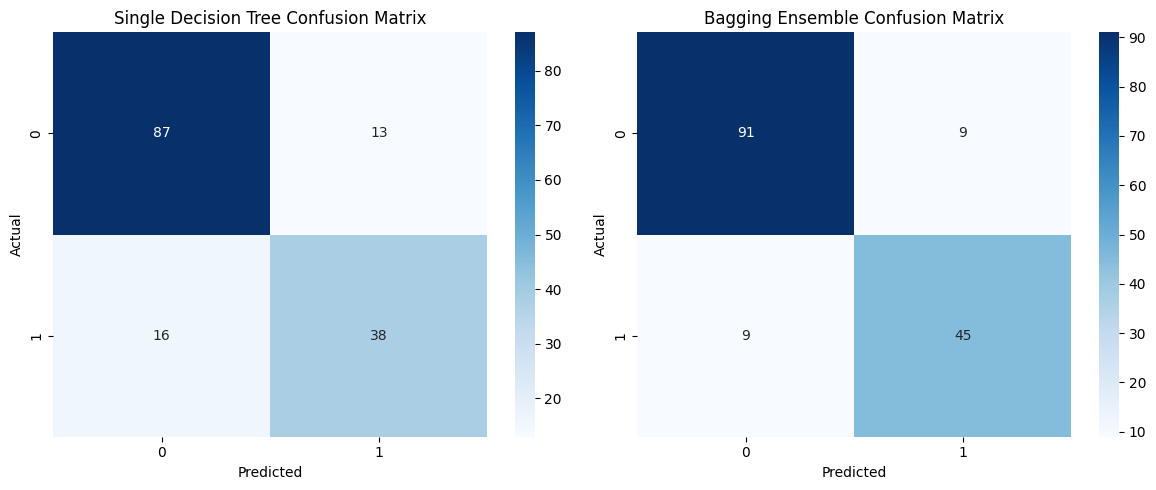

In [9]:
# 1. Train a standalone, single DecisionTreeClassifier on the original training data
single_tree_model = DecisionTreeClassifier(max_depth=None, random_state=42)
single_tree_model.fit(X_train, y_train)

# 2. Predict the classes for X_test using both the single tree and the custom Bagging classifier
y_pred_single_tree = single_tree_model.predict(X_test)
y_pred_bagging = custom_bagging_predict(ensemble, X_test)

# 3. Construct Confusion Matrix for both models
conf_matrix_single_tree = confusion_matrix(y_test, y_pred_single_tree)
conf_matrix_bagging = confusion_matrix(y_test, y_pred_bagging)

print("\n--- Single Decision Tree Performance ---")
print("Confusion Matrix:\n", conf_matrix_single_tree)
print(f"Accuracy: {accuracy_score(y_test, y_pred_single_tree):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_single_tree):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_single_tree):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_single_tree):.4f}")

print("\n--- Custom Bagging Ensemble Performance ---")
print("Confusion Matrix:\n", conf_matrix_bagging)
print(f"Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_bagging):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_bagging):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_bagging):.4f}")

# Plotting Confusion Matrices for better visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(conf_matrix_single_tree, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Single Decision Tree Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_xticklabels(['0', '1'])
axes[0].set_yticklabels(['0', '1'])

sns.heatmap(conf_matrix_bagging, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Bagging Ensemble Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_xticklabels(['0', '1'])
axes[1].set_yticklabels(['0', '1'])

plt.tight_layout()
plt.show()

#### **Task 9: ROC-AUC Analysis and Curve Visualization**

- **Goal:** Measure classification performance at different thresholds.

- **Instructions:**
  1. Calculate predicted class probabilities by averaging the probability estimates (\(\texttt{predict\_proba}\)) across all \(B\) decision trees in your custom Bagging model.
  2. Plot the **Receiver Operating Characteristic (ROC) curve** for both the single decision tree and the custom Bagging model on a single chart.
  3. Compute and contrast the **Area Under the Curve (AUC)** for both configurations, noting the improvement.

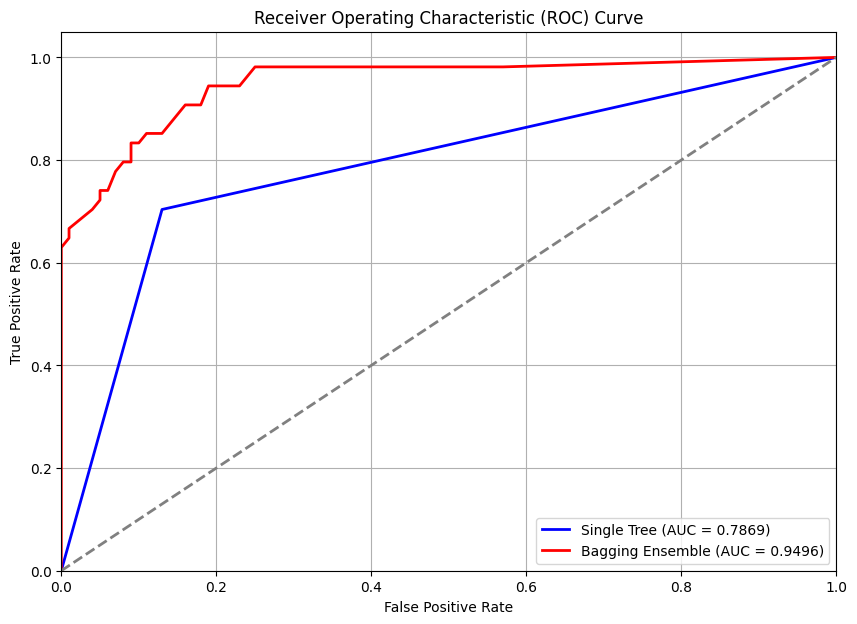


AUC for Single Decision Tree: 0.7869
AUC for Custom Bagging Ensemble: 0.9496

Observation: The Bagging Ensemble shows a better AUC, indicating superior overall discrimination capability.


In [10]:
# 1. Calculate predicted class probabilities for the single decision tree
y_prob_single_tree = single_tree_model.predict_proba(X_test)[:, 1]

# 2. Calculate predicted class probabilities for the custom Bagging model
# Average the predict_proba from each tree in the ensemble
probabilities = np.array([model.predict_proba(X_test)[:, 1] for model in ensemble])
y_prob_bagging = np.mean(probabilities, axis=0)

# 3. Plot the Receiver Operating Characteristic (ROC) curve for both models
fpr_single_tree, tpr_single_tree, _ = roc_curve(y_test, y_prob_single_tree)
roc_auc_single_tree = auc(fpr_single_tree, tpr_single_tree)

fpr_bagging, tpr_bagging, _ = roc_curve(y_test, y_prob_bagging)
roc_auc_bagging = auc(fpr_bagging, tpr_bagging)

plt.figure(figsize=(10, 7))
plt.plot(fpr_single_tree, tpr_single_tree, color='blue', lw=2, label=f'Single Tree (AUC = {roc_auc_single_tree:.4f})')
plt.plot(fpr_bagging, tpr_bagging, color='red', lw=2, label=f'Bagging Ensemble (AUC = {roc_auc_bagging:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 4. Compute and contrast the Area Under the Curve (AUC) for both configurations
print(f"\nAUC for Single Decision Tree: {roc_auc_single_tree:.4f}")
print(f"AUC for Custom Bagging Ensemble: {roc_auc_bagging:.4f}")

if roc_auc_bagging > roc_auc_single_tree:
    print("\nObservation: The Bagging Ensemble shows a better AUC, indicating superior overall discrimination capability.")
else:
    print("\nObservation: The Single Decision Tree shows better or similar AUC.")

#### **Task 10: Validation against Scikit-Learn's BaggingClassifier**

- **Goal:** Verify custom code correctness.

- **Instructions:**
  1. Instantiate Scikit-Learn's built-in \(\texttt{BaggingClassifier}\) using \(\texttt{DecisionTreeClassifier(max\_depth=None)}\) as the base estimator and \(\texttt{n\_estimators=50}\).
  2. Fit the classifier on the training set and evaluate it on the test set.
  3. Compare the resulting test accuracy and confusion matrix against your custom implementation from **Task 7** and **Task 8** to validate your custom bootstrap and aggregation logic.


--- Scikit-Learn's BaggingClassifier Performance ---
Confusion Matrix:
 [[91  9]
 [ 9 45]]
Accuracy: 0.8831
Precision: 0.8333
Recall: 0.8333
F1-Score: 0.8333

--- Comparison with Custom Bagging Ensemble (from Task 8) ---
Custom Bagging Accuracy: 0.8831
Custom Bagging Precision: 0.8333
Custom Bagging Recall: 0.8333
Custom Bagging F1-Score: 0.8333


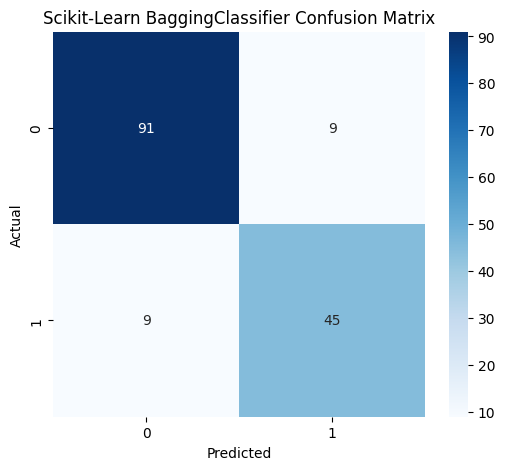

In [12]:
from sklearn.ensemble import BaggingClassifier

# 1. Instantiate Scikit-Learn's built-in BaggingClassifier
sk_bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=None, random_state=42),
    n_estimators=50,
    random_state=42, # For reproducibility of the overall BaggingClassifier
    bootstrap=True,  # Default, but explicit for clarity
    n_jobs=-1        # Use all available CPU cores
)

# 2. Fit the classifier on the training set
sk_bagging_model.fit(X_train, y_train)

# Predict on the test set using Scikit-Learn's BaggingClassifier
y_pred_sk_bagging = sk_bagging_model.predict(X_test)

# 3. Compare the resulting test accuracy and confusion matrix against custom implementation
print("\n--- Scikit-Learn's BaggingClassifier Performance ---")
conf_matrix_sk_bagging = confusion_matrix(y_test, y_pred_sk_bagging)
print("Confusion Matrix:\n", conf_matrix_sk_bagging)
print(f"Accuracy: {accuracy_score(y_test, y_pred_sk_bagging):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_sk_bagging):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_sk_bagging):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_sk_bagging):.4f}")

print("\n--- Comparison with Custom Bagging Ensemble (from Task 8) ---")
# Recall values from previous outputs for easy comparison
print(f"Custom Bagging Accuracy: {accuracy_score(y_test, y_pred_bagging):.4f}")
print(f"Custom Bagging Precision: {precision_score(y_test, y_pred_bagging):.4f}")
print(f"Custom Bagging Recall: {recall_score(y_test, y_pred_bagging):.4f}")
print(f"Custom Bagging F1-Score: {f1_score(y_test, y_pred_bagging):.4f}")

# Plotting Confusion Matrix for Scikit-Learn's BaggingClassifier
plt.figure(figsize=(6, 5))
ax = sns.heatmap(conf_matrix_sk_bagging, annot=True, fmt='d', cmap='Blues')
ax.set_title("Scikit-Learn BaggingClassifier Confusion Matrix")
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_xticklabels(['0', '1'])
ax.set_yticklabels(['0', '1'])
plt.show()

### **Conclusion and Interpretation**

Students should summarize their findings by answering the following key questions:

1. **Variance and Stability:** How does the test accuracy of the Bagging ensemble compare to the single decision tree? Why does Bagging provide more consistent performance across different train-test splits?

2. **Wisdom of Crowds:** How does random resampling with replacement (bootstrapping) foster model diversity, and how does the consensus voting rule translate to a "Wisdom of Crowds" effect?

3. **Clinical Interpretation:** In predicting diabetes, why are False Negatives (predicting non-diabetic for a diabetic patient) especially costly, and how does Bagging's Recall metric help minimize this risk compared to a single decision tree?